In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings


sys.path.append('../src')
from db_connection import get_connection

warnings.filterwarnings("ignore")

conn = get_connection()
print("Ready!")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)


 Connected to revenue_leak_db as postgres
Ready!


C:\Users\josel\AppData\Local\Temp\ipykernel_34876\2540262614.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_revenue = pd.read_sql(query, conn)
C:\Users\josel\AppData\Local\Temp\ipykernel_34876\2540262614.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_revenue, x="total_revenue", y="category", palette="viridis", ax=ax)


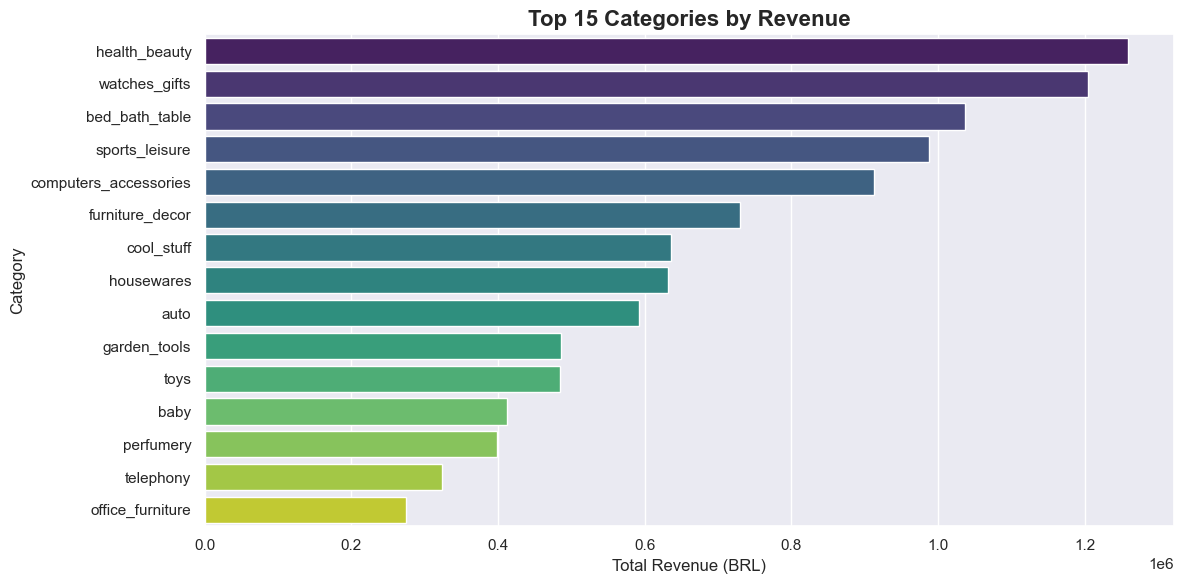

,category,total_revenue,total_orders
0,health_beauty,1258681.34,8836
1,watches_gifts,1205005.68,5624
2,bed_bath_table,1036988.68,9417
3,sports_leisure,988048.97,7720
4,computers_accessories,911954.32,6689
5,furniture_decor,729762.49,6449
6,cool_stuff,635290.85,3632
7,housewares,632248.66,5884
8,auto,592720.11,3897
9,garden_tools,485256.46,3518


In [16]:
query = """
    SELECT 
        p.product_category_name_english AS category,
        ROUND(SUM(oi.price)::NUMERIC, 2) AS total_revenue,
        COUNT(DISTINCT oi.order_id)      AS total_orders
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    WHERE p.product_category_name_english != 'unknown'
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 15;
"""

df_revenue = pd.read_sql(query, conn)

# Plot
fig, ax = plt.subplots()
sns.barplot(data=df_revenue, x="total_revenue", y="category", palette="viridis", ax=ax)
ax.set_title("Top 15 Categories by Revenue", fontsize=16, fontweight="bold")
ax.set_xlabel("Total Revenue (BRL)")
ax.set_ylabel("Category")
plt.tight_layout()
plt.savefig("../visuals/revenue_by_category.png", dpi=150)
plt.show()

df_revenue

C:\Users\josel\AppData\Local\Temp\ipykernel_34876\1205946681.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_freight = pd.read_sql(query, conn)
C:\Users\josel\AppData\Local\Temp\ipykernel_34876\1205946681.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_freight, x="freight_pct", y="category", palette="rocket", ax=ax)


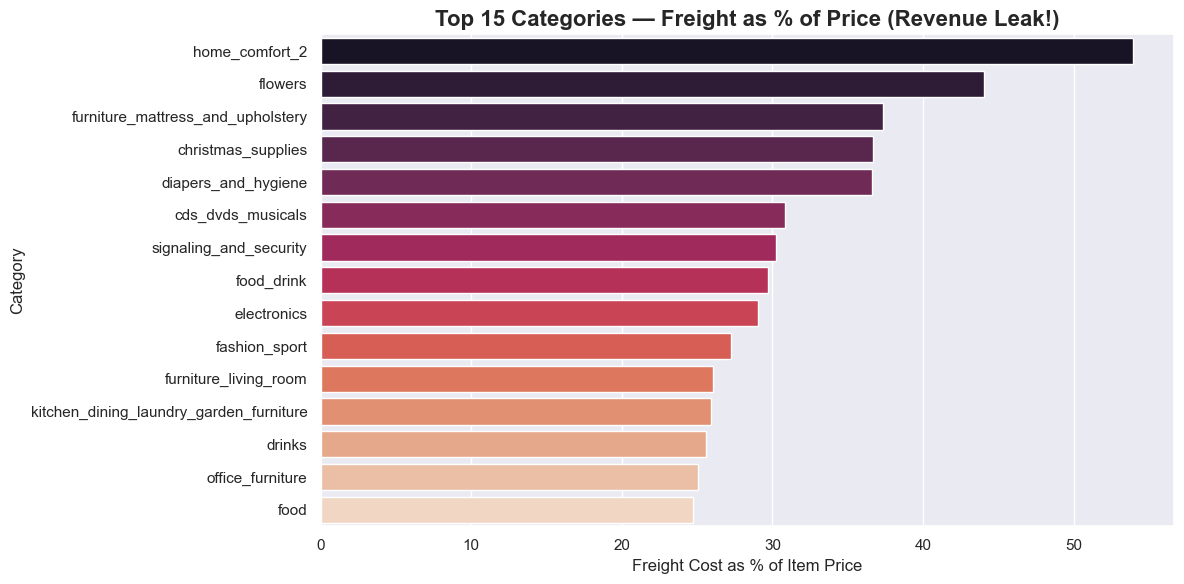

,category,avg_price,avg_freight,freight_pct
0,home_comfort_2,25.34,13.68,53.97
1,flowers,33.64,14.81,44.04
2,furniture_mattress_and_upholstery,114.95,42.91,37.33
3,christmas_supplies,57.52,21.11,36.69
4,diapers_and_hygiene,40.19,14.71,36.60
5,cds_dvds_musicals,52.14,16.07,30.82
6,signaling_and_security,108.09,32.70,30.26
7,food_drink,54.60,16.22,29.70
8,electronics,57.91,16.83,29.07
9,fashion_sport,70.65,19.27,27.28


In [4]:
query = """
    SELECT 
        p.product_category_name_english AS category,
        ROUND(AVG(oi.price)::NUMERIC, 2)         AS avg_price,
        ROUND(AVG(oi.freight_value)::NUMERIC, 2)  AS avg_freight,
        ROUND((AVG(oi.freight_value) / NULLIF(AVG(oi.price), 0) * 100)::NUMERIC, 2) AS freight_pct
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    WHERE p.product_category_name_english != 'unknown'
    GROUP BY category
    ORDER BY freight_pct DESC
    LIMIT 15;
"""

df_freight = pd.read_sql(query, conn)

fig, ax = plt.subplots()
sns.barplot(data=df_freight, x="freight_pct", y="category", palette="rocket", ax=ax)
ax.set_title("Top 15 Categories — Freight as % of Price (Revenue Leak!)", fontsize=16, fontweight="bold")
ax.set_xlabel("Freight Cost as % of Item Price")
ax.set_ylabel("Category")
plt.tight_layout()
plt.savefig("../visuals/freight_vs_price.png", dpi=150)
plt.show()

df_freight

C:\Users\josel\AppData\Local\Temp\ipykernel_34876\2447940840.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_status = pd.read_sql(query, conn)


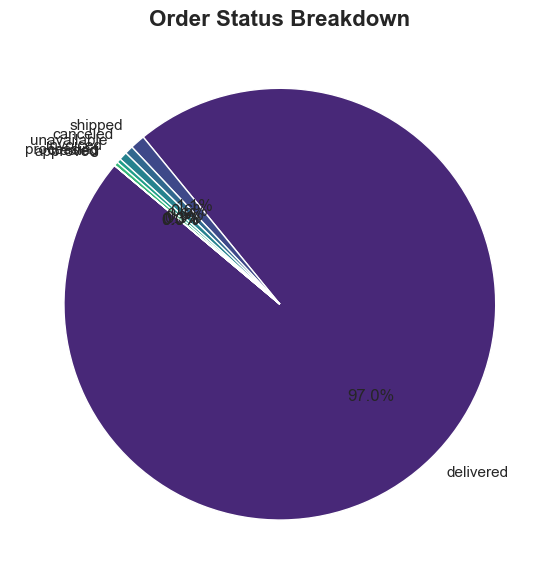

,order_status,total,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [5]:
query = """
    SELECT 
        order_status,
        COUNT(*) AS total,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
    FROM orders
    GROUP BY order_status
    ORDER BY total DESC;
"""

df_status = pd.read_sql(query, conn)

fig, ax = plt.subplots()
ax.pie(
    df_status["total"],
    labels=df_status["order_status"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("viridis", len(df_status))
)
ax.set_title("Order Status Breakdown", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../visuals/order_status.png", dpi=150)
plt.show()

df_status

C:\Users\josel\AppData\Local\Temp\ipykernel_34876\2094743635.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trend = pd.read_sql(query, conn)


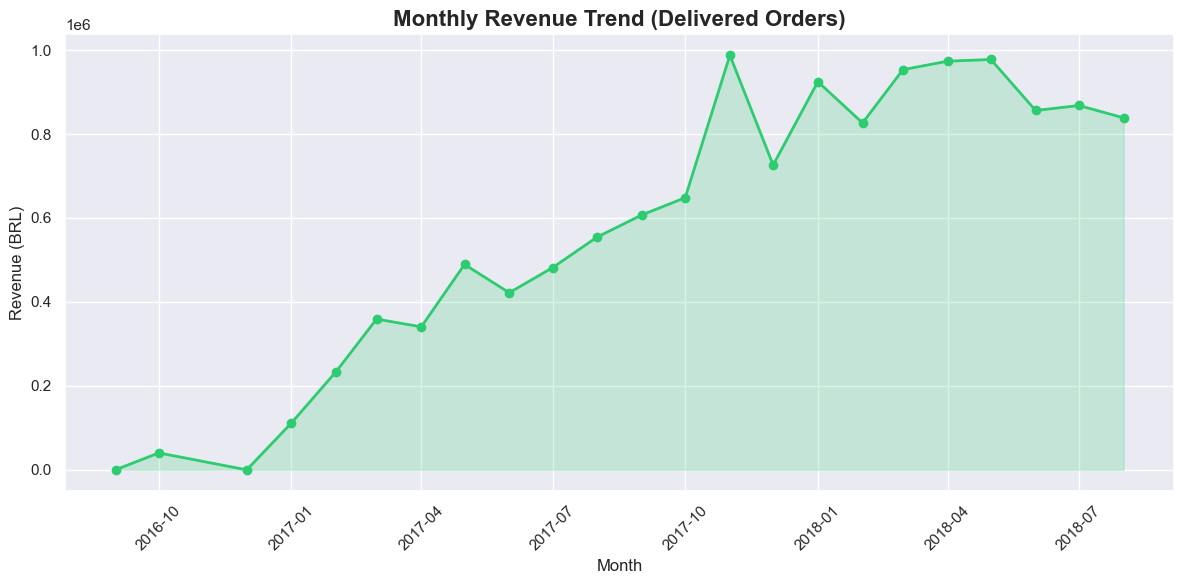

,month,monthly_revenue
0,2016-09-01,134.97
1,2016-10-01,40325.11
2,2016-12-01,10.90
3,2017-01-01,111798.36
4,2017-02-01,234223.40
5,2017-03-01,359198.85
6,2017-04-01,340669.68
7,2017-05-01,489338.25
8,2017-06-01,421923.37
9,2017-07-01,481604.52


In [6]:
query = """
    SELECT 
        DATE_TRUNC('month', o.order_purchase_timestamp::TIMESTAMP) AS month,
        ROUND(SUM(oi.price)::NUMERIC, 2) AS monthly_revenue
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY month
    ORDER BY month;
"""

df_trend = pd.read_sql(query, conn)
df_trend["month"] = pd.to_datetime(df_trend["month"])

fig, ax = plt.subplots()
ax.plot(df_trend["month"], df_trend["monthly_revenue"], marker="o", color="#2ecc71", linewidth=2)
ax.fill_between(df_trend["month"], df_trend["monthly_revenue"], alpha=0.2, color="#2ecc71")
ax.set_title("Monthly Revenue Trend (Delivered Orders)", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (BRL)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/monthly_trend.png", dpi=150)
plt.show()

df_trend

C:\Users\josel\AppData\Local\Temp\ipykernel_34876\785937751.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customers = pd.read_sql(query, conn)
C:\Users\josel\AppData\Local\Temp\ipykernel_34876\785937751.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_customers, x="total_spent", y="customer_unique_id", palette="Blues_r", ax=ax)


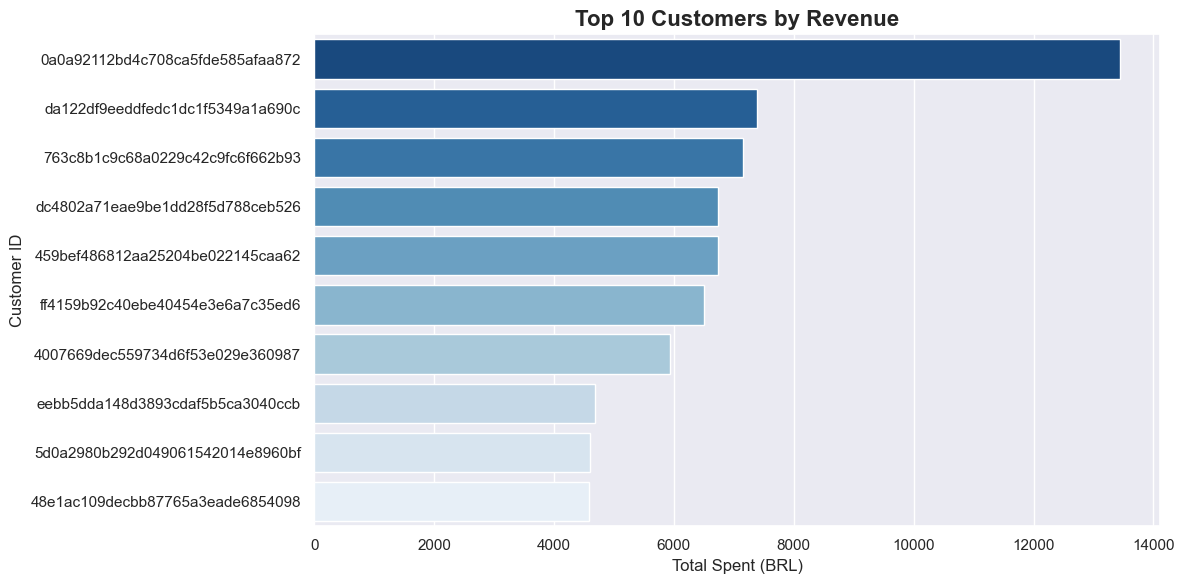

,customer_unique_id,customer_city,customer_state,total_spent,total_orders
0,0a0a92112bd4c708ca5fde585afaa872,rio de janeiro,RJ,13440.0,1
1,da122df9eeddfedc1dc1f5349a1a690c,araruama,RJ,7388.0,2
2,763c8b1c9c68a0229c42c9fc6f662b93,vila velha,ES,7160.0,1
3,dc4802a71eae9be1dd28f5d788ceb526,campo grande,MS,6735.0,1
4,459bef486812aa25204be022145caa62,vitoria,ES,6729.0,1
5,ff4159b92c40ebe40454e3e6a7c35ed6,marilia,SP,6499.0,1
6,4007669dec559734d6f53e029e360987,divinopolis,MG,5934.6,1
7,eebb5dda148d3893cdaf5b5ca3040ccb,maua,SP,4690.0,1
8,5d0a2980b292d049061542014e8960bf,goiania,GO,4599.9,1
9,48e1ac109decbb87765a3eade6854098,joao pessoa,PB,4590.0,1


In [7]:
query = """
    SELECT 
        c.customer_unique_id,
        c.customer_city,
        c.customer_state,
        ROUND(SUM(oi.price)::NUMERIC, 2) AS total_spent,
        COUNT(DISTINCT o.order_id)        AS total_orders
    FROM customers c
    JOIN orders o      ON c.customer_id  = o.customer_id
    JOIN order_items oi ON o.order_id   = oi.order_id
    GROUP BY c.customer_unique_id, c.customer_city, c.customer_state
    ORDER BY total_spent DESC
    LIMIT 10;
"""

df_customers = pd.read_sql(query, conn)

fig, ax = plt.subplots()
sns.barplot(data=df_customers, x="total_spent", y="customer_unique_id", palette="Blues_r", ax=ax)
ax.set_title("Top 10 Customers by Revenue", fontsize=16, fontweight="bold")
ax.set_xlabel("Total Spent (BRL)")
ax.set_ylabel("Customer ID")
plt.tight_layout()
plt.savefig("../visuals/top_customers.png", dpi=150)
plt.show()

df_customers

In [8]:
query = """
    SELECT 
        p.product_id,
        p.product_category_name_english AS category,
        ROUND(SUM(oi.price)::NUMERIC, 2) AS total_revenue
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    WHERE p.product_category_name_english != 'unknown'
    GROUP BY p.product_id, p.product_category_name_english
    ORDER BY total_revenue DESC;
"""

df_pareto = pd.read_sql(query, conn)

# Calculate cumulative revenue percentage
df_pareto["cumulative_revenue"] = df_pareto["total_revenue"].cumsum()
df_pareto["cumulative_pct"]     = df_pareto["cumulative_revenue"] / df_pareto["total_revenue"].sum() * 100
df_pareto["product_pct"]        = range(1, len(df_pareto) + 1)
df_pareto["product_pct"]        = df_pareto["product_pct"] / len(df_pareto) * 100

df_pareto.head(10)

C:\Users\josel\AppData\Local\Temp\ipykernel_34876\1569659446.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pareto = pd.read_sql(query, conn)


,product_id,category,total_revenue,cumulative_revenue,cumulative_pct,product_pct
0,bb50f2e236e5eea0100680137654686c,health_beauty,63885.00,63885.00,0.476519,0.003093
1,6cdd53843498f92890544667809f1595,health_beauty,54730.20,118615.20,0.884753,0.006187
2,d6160fb7873f184099d9bc95e30376af,computers,48899.34,167514.54,1.249494,0.009280
3,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,47214.51,214729.05,1.601667,0.012373
4,99a4788cb24856965c36a24e339b6058,bed_bath_table,43025.56,257754.61,1.922596,0.015466
5,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,41082.60,298837.21,2.229032,0.018560
6,25c38557cf793876c5abdd5931f922db,baby,38907.32,337744.53,2.519242,0.021653
7,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,37733.90,375478.43,2.800700,0.024746
8,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,37683.42,413161.85,3.081781,0.027840
9,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,37608.90,450770.75,3.362306,0.030933


In [9]:
# Find what % of products generate 80% of revenue
crossover = df_pareto[df_pareto["cumulative_pct"] >= 80].iloc[0]
product_pct_at_80 = crossover["product_pct"]

print(f"📊 80/20 RULE RESULTS:")
print(f"   Top {product_pct_at_80:.1f}% of products generate 80% of revenue")
print(f"   That's {int(len(df_pareto) * product_pct_at_80 / 100)} products out of {len(df_pareto)} total")
print(f"   Total revenue: R${df_pareto['total_revenue'].sum():,.2f}")

📊 80/20 RULE RESULTS:
   Top 26.0% of products generate 80% of revenue
   That's 8411 products out of 32328 total
   Total revenue: R$13,406,593.94


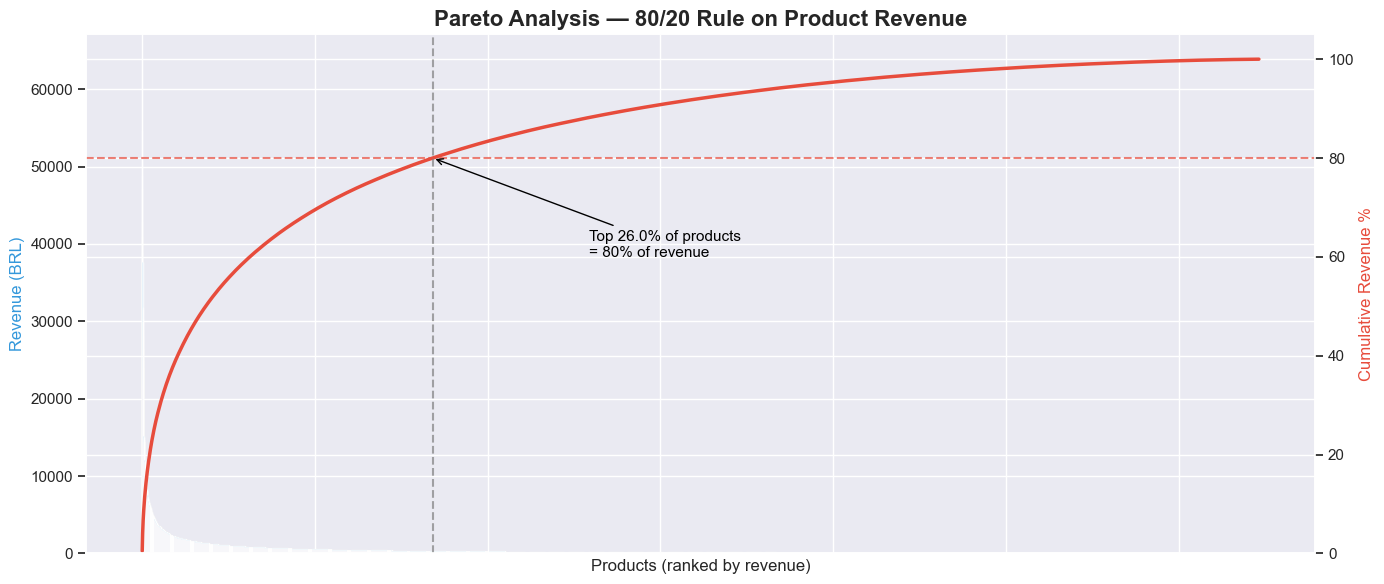

In [10]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart — individual product revenue
ax1.bar(
    range(len(df_pareto)),
    df_pareto["total_revenue"],
    color="#3498db",
    alpha=0.6,
    label="Product Revenue"
)
ax1.set_xlabel("Products (ranked by revenue)", fontsize=12)
ax1.set_ylabel("Revenue (BRL)", fontsize=12, color="#3498db")
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Line chart — cumulative % on second axis
ax2 = ax1.twinx()
ax2.plot(
    range(len(df_pareto)),
    df_pareto["cumulative_pct"],
    color="#e74c3c",
    linewidth=2.5,
    label="Cumulative Revenue %"
)
ax2.axhline(y=80, color="#e74c3c", linestyle="--", alpha=0.7)
ax2.axvline(x=int(len(df_pareto) * product_pct_at_80 / 100),
            color="gray", linestyle="--", alpha=0.7)
ax2.set_ylabel("Cumulative Revenue %", fontsize=12, color="#e74c3c")
ax2.set_ylim(0, 105)

# Annotation
ax2.annotate(
    f"Top {product_pct_at_80:.1f}% of products\n= 80% of revenue",
    xy=(int(len(df_pareto) * product_pct_at_80 / 100), 80),
    xytext=(int(len(df_pareto) * 0.4), 60),
    fontsize=11,
    color="black",
    arrowprops=dict(arrowstyle="->", color="black")
)

ax1.set_title("Pareto Analysis — 80/20 Rule on Product Revenue", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.savefig("../visuals/pareto_80_20.png", dpi=150)
plt.show()

In [11]:
# These are products dragging down revenue
bottom_20 = df_pareto.tail(int(len(df_pareto) * 0.2))

print(f"🚨 BOTTOM 20% PRODUCTS:")
print(f"   Count : {len(bottom_20)} products")
print(f"   Total Revenue: R${bottom_20['total_revenue'].sum():,.2f}")
print(f"   Avg Revenue per product: R${bottom_20['total_revenue'].mean():,.2f}")
print(f"\n   Top categories in bottom 20%:")
print(bottom_20["category"].value_counts().head(10))

🚨 BOTTOM 20% PRODUCTS:
   Count : 6465 products
   Total Revenue: R$200,994.85
   Avg Revenue per product: R$31.09

   Top categories in bottom 20%:
category
housewares                  657
furniture_decor             550
sports_leisure              526
telephony                   493
health_beauty               445
bed_bath_table              418
auto                        397
fashion_bags_accessories    332
computers_accessories       287
toys                        222
Name: count, dtype: int64


In [22]:
#RFM

query = """
    SELECT 
        c.customer_unique_id,
        MAX(o.order_purchase_timestamp::TIMESTAMP)  AS last_purchase,
        COUNT(DISTINCT o.order_id)                   AS frequency,
        ROUND(SUM(oi.price)::NUMERIC, 2)             AS monetary
    FROM customers c
    JOIN orders o       ON c.customer_id  = o.customer_id
    JOIN order_items oi ON o.order_id     = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id;
"""

df_rfm = pd.read_sql(query, conn)

# Recency = days since last purchase
import datetime
snapshot_date = df_rfm["last_purchase"].max() + datetime.timedelta(days=1)
df_rfm["recency"] = (snapshot_date - df_rfm["last_purchase"]).dt.days

df_rfm = df_rfm[["customer_unique_id", "recency", "frequency", "monetary"]]
df_rfm.head()

C:\Users\josel\AppData\Local\Temp\ipykernel_34876\1102867552.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_rfm = pd.read_sql(query, conn)


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


In [18]:
# Score 5 = best, 1 = worst
# Recency: lower days = better = score 5
df_rfm["R"] = pd.qcut(df_rfm["recency"],   q=5, labels=[5,4,3,2,1])
df_rfm["F"] = pd.qcut(df_rfm["frequency"].rank(method="first"), q=5, labels=[1,2,3,4,5])
df_rfm["M"] = pd.qcut(df_rfm["monetary"],  q=5, labels=[1,2,3,4,5])

df_rfm["RFM_Score"] = df_rfm["R"].astype(str) + df_rfm["F"].astype(str) + df_rfm["M"].astype(str)
df_rfm["Total_Score"] = df_rfm[["R","F","M"]].astype(int).sum(axis=1)

df_rfm.head(10)

,customer_unique_id,recency,frequency,monetary,R,F,M,RFM_Score,Total_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,414,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,411,6
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,112,4
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,215,8
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,154.00,4,1,4,414,9
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,27.99,4,1,1,411,6
7,00053a61a98854899e70ed204dd4bafe,183,1,382.00,3,1,5,315,9
8,0005e1862207bf6ccc02e4228effd9a0,543,1,135.00,1,1,4,114,6
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,104.90,4,1,3,413,8


In [19]:
def assign_segment(row):
    r = int(row["R"])
    f = int(row["F"])
    m = int(row["M"])
    score = r + f + m

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    elif r == 1 and f == 1:
        return "Lost"
    elif score >= 9:
        return "Potential Loyalists"
    else:
        return "Needs Attention"

df_rfm["Segment"] = df_rfm.apply(assign_segment, axis=1)

# Summary
segment_summary = df_rfm.groupby("Segment").agg(
    customer_count=("customer_unique_id", "count"),
    avg_recency   =("recency",   "mean"),
    avg_frequency =("frequency", "mean"),
    avg_monetary  =("monetary",  "mean"),
    total_revenue =("monetary",  "sum")
).round(2).sort_values("total_revenue", ascending=False)

print(segment_summary)

                     customer_count  avg_recency  avg_frequency  avg_monetary  \
Segment                                                                         
At Risk                       12857       393.00           1.07        218.38   
Loyal Customers               13689       154.38           1.06        184.36   
New Customers                 14984        90.88           1.00        139.31   
Needs Attention               27534       332.70           1.00         75.45   
Champions                      6449        91.31           1.17        275.76   
Potential Loyalists           14018       151.40           1.01        100.91   
Lost                           3827       474.08           1.00        139.10   

                     total_revenue  
Segment                             
At Risk                 2807692.35  
Loyal Customers         2523704.02  
New Customers           2087427.21  
Needs Attention         2077344.15  
Champions               1778394.92  
Potential L

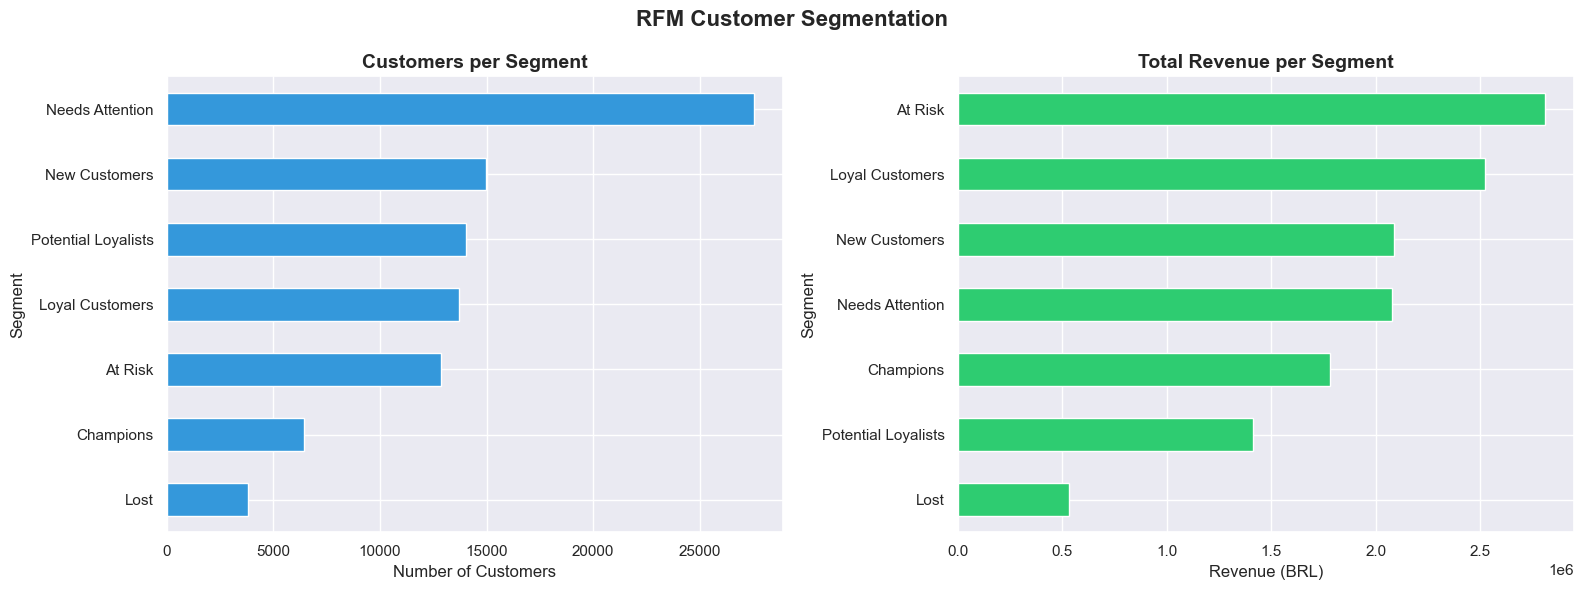

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Customer count per segment
segment_summary["customer_count"].sort_values().plot(
    kind="barh", ax=axes[0], color="#3498db"
)
axes[0].set_title("Customers per Segment", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of Customers")

# Chart 2 — Revenue per segment  
segment_summary["total_revenue"].sort_values().plot(
    kind="barh", ax=axes[1], color="#2ecc71"
)
axes[1].set_title("Total Revenue per Segment", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Revenue (BRL)")

plt.suptitle("RFM Customer Segmentation", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../visuals/rfm_segments.png", dpi=150)
plt.show()

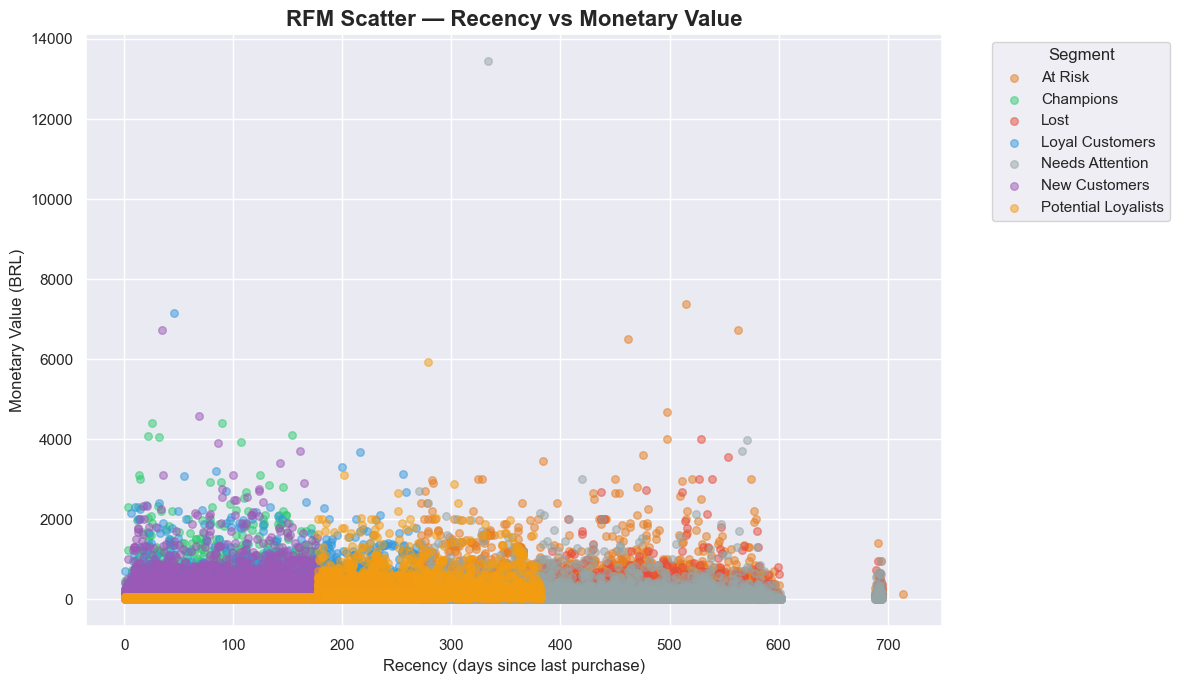

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = {
    "Champions":         "#2ecc71",
    "Loyal Customers":   "#3498db",
    "New Customers":     "#9b59b6",
    "Potential Loyalists":"#f39c12",
    "At Risk":           "#e67e22",
    "Needs Attention":   "#95a5a6",
    "Lost":              "#e74c3c",
}

for segment, group in df_rfm.groupby("Segment"):
    ax.scatter(
        group["recency"],
        group["monetary"],
        label=segment,
        alpha=0.5,
        s=30,
        color=colors.get(segment, "gray")
    )

ax.set_title("RFM Scatter — Recency vs Monetary Value", fontsize=16, fontweight="bold")
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("Monetary Value (BRL)")
ax.legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../visuals/rfm_scatter.png", dpi=150)
plt.show()

In [ ]:
#conn.close()
#print("Connection closed.")

Connection closed.
